# SARSA Algorithm

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement SARSA and compare with Q-learning
- Understand on-policy vs off-policy

## 🔗 Prerequisites

- ✅ Basic Python
- ✅ Basic NumPy/Pandas (when applicable)

---

## Official Structure Reference

This notebook belongs to **Course 09, Unit 2**.

---


## Lesson Brief

This lesson introduces **SARSA**, an on-policy alternative to Q-learning.

Students will compare how learning changes when updates depend on the action the agent actually follows, not only the greedy action estimate.

Why this matters: SARSA helps students understand that not all value-learning methods make the same assumptions about behavior and learning.

It is also a good lesson for discussing safer or more conservative learning behavior.

## Recommended YouTube Video

To reinforce this lesson, watch **deeplizard - "How to Code SARSA with Just Numpy"**:
[Watch on YouTube](https://www.youtube.com/watch?v=gJZwXkXDFEI)

Why this pick:
- coding-first explanation.
- Helps students see the on-policy nature of SARSA in a concrete update loop.
- Good companion when comparing SARSA against Q-learning.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- On-policy: learns from the actions actually taken by the current behavior policy.
- Next action: part of the SARSA update target.
- Behavior policy: the policy generating the data.
- Update target: the value the estimate moves toward.
- Exploration-aware learning: updates reflect the fact that the policy is still exploring.

### Quick Check
- Why does SARSA use the next chosen action?
- How can SARSA become more cautious?
- What makes SARSA on-policy?
- Why can exploration change the learned behavior itself?

### Common Mistakes
- Thinking SARSA equals Q-learning.
- Ignoring exploration in the update.
- Missing how the next action changes behavior.
- Forgetting that SARSA learns the value of the policy it is actually following.


## SARSA vs Q-Learning in Plain Language

Students often ask: if both algorithms update action values, why do we need both?

### Q-learning

Q-learning asks:

`What is the best next action I could take from the next state?`

So it learns toward a greedy target, even if the current behavior policy is still exploring.

### SARSA

SARSA asks:

`What action did I actually choose next, and what is its value?`

So the update includes the real next action produced by the current policy.

### Why does this matter?

If the current policy still explores, SARSA learns a value function that already reflects that exploration risk.
This often makes SARSA look more cautious than Q-learning.

### Memory trick

SARSA is named from the update pieces:

- State
- Action
- Reward
- State
- Action

That final action is the clue that the update depends on the next action actually taken.

## Inputs and Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---


### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [1]:
# Teaching note: this cell advances the lesson by building the next piece of the RL workflow.
# Run it after reading the comments so the output feels connected to the concept being taught.

"""
AIAT 123 - SARSA Algorithm
SARSA Algorithm
"""

# Import names from a package/module into the notebook kernel namespace.
import numpy as np
# Import names from a package/module into the notebook kernel namespace.
import matplotlib.pyplot as plt

# Print text to the notebook cell output (console).
print("=" * 70)
# Print text to the notebook cell output (console).
print("SARSA Algorithm")
# Print text to the notebook cell output (console).
print("=" * 70)

# Implementation here
# Print text to the notebook cell output (console).
print("\n✅ Notebook ready for implementation!")


SARSA Algorithm

✅ Notebook ready for implementation!


## 🌍 Real-World Worked Example — Inventory Management with SARSA

**Industry context:**
- Amazon uses RL to optimise warehouse robot routing
- Google DeepMind reduced data centre cooling costs by 40% using RL
- Uber uses RL for dynamic surge pricing

We model a simple **inventory replenishment** problem as an MDP and solve it with **SARSA**, so the update reflects the action the policy actually chooses next.

### Step Guide

**What this cell does:** This cell runs a worked example and shows the result through printed values, tables, or plots.

**Why this matters:** It is where the theory becomes concrete and students can connect the idea to actual behavior.

**What to expect in the output:** Expect visible output such as trajectories, value updates, rewards, comparisons, or charts.

**Common student confusion:** Students should compare the output with the comments and ask: what changed, why did it change, and what does that mean?


SARSA policy suggestion:
  Stock= 0 → RESTOCK
  Stock= 1 → RESTOCK
  Stock= 2 → RESTOCK
  Stock= 3 → RESTOCK
  Stock= 4 → RESTOCK
  Stock= 5 → Do NOT restock
  Stock= 6 → Do NOT restock
  Stock= 7 → Do NOT restock
  Stock= 8 → Do NOT restock
  Stock= 9 → Do NOT restock
  Stock=10 → Do NOT restock


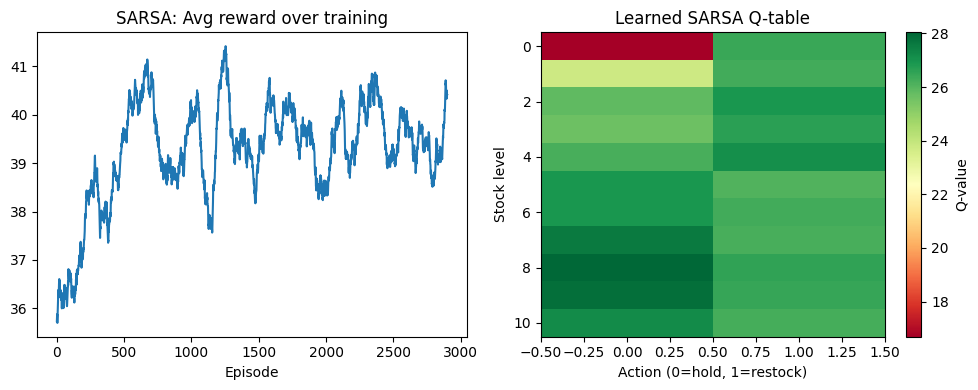

In [2]:
# Worked example: run SARSA on the same inventory environment so the update target stays on-policy.
# Notice that the next chosen action is part of the update, not just the greedy action value.

# Import names from a package/module into the notebook kernel namespace.
import numpy as np, matplotlib.pyplot as plt

# Call a NumPy helper (array creation, options, or array conversion).
np.random.seed(42)

# ── Environment: Inventory Management ─────────────────────────────────────
# State: stock level 0..10. Action: 0=don't restock, 1=restock (+5 units).
# Each day: sell 0-3 units (random). Reward: +1 per unit sold, -2 if out of stock.
# Assign/update a variable used later in this cell or in other cells.
MAX_STOCK = 10
# Assign/update a variable used later in this cell or in other cells.
n_states, n_actions = MAX_STOCK + 1, 2

# Function `step` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: state, action.
def step(state, action):
    # Assign/update a variable used later in this cell or in other cells.
    new_s = min(state + action * 5, MAX_STOCK)
    # Assign/update a variable used later in this cell or in other cells.
    demand = np.random.randint(0, 4)
    # Assign/update a variable used later in this cell or in other cells.
    sold = min(new_s, demand)
    # Unpack the one-step model output from transition(state, action).
    reward = sold - (2 if demand > new_s else 0) - (0.5 * action)
    # Assign/update a variable used later in this cell or in other cells.
    new_s = max(new_s - demand, 0)
    # Return a value from this function to its caller.
    return new_s, reward

# Function `choose_action` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: q_table, state, eps.
def choose_action(q_table, state, eps):
    # Return a value from this function to its caller.
    return np.random.randint(n_actions) if np.random.rand() < eps else int(np.argmax(q_table[state]))

# ── SARSA ──────────────────────────────────────────────────────────────────
# Assign/update a variable used later in this cell or in other cells.
Q = np.zeros((n_states, n_actions))
# Assign/update a variable used later in this cell or in other cells.
alpha = 0.1; gamma = 0.95
# Assign/update a variable used later in this cell or in other cells.
eps = 1.0; eps_min = 0.05; eps_decay = 0.995
# Unpack the one-step model output from transition(state, action).
rewards_history = []

# Loop header: repeat the indented block for each item in the iterable.
for episode in range(3000):
    # Create or choose a variable used in the Bellman warm-up demo.
    state = np.random.randint(0, MAX_STOCK + 1)
    # Assign/update a variable used later in this cell or in other cells.
    action = choose_action(Q, state, eps)
    # Assign/update a variable used later in this cell or in other cells.
    total_r = 0

    # Loop header: repeat the indented block for each item in the iterable.
    for _ in range(30):
        # Unpack the one-step model output from transition(state, action).
        next_state, reward = step(state, action)
        # Assign/update a variable used later in this cell or in other cells.
        next_action = choose_action(Q, next_state, eps)
        # Assign/update a variable used later in this cell or in other cells.
        td_target = reward + gamma * Q[next_state, next_action]
        # Assign/update a variable used later in this cell or in other cells.
        Q[state, action] += alpha * (td_target - Q[state, action])
        # Assign/update a variable used later in this cell or in other cells.
        state, action = next_state, next_action
        # Assign/update a variable used later in this cell or in other cells.
        total_r += reward

    # Append one value to a list (mutates the list in place).
    rewards_history.append(total_r)
    # Assign/update a variable used later in this cell or in other cells.
    eps = max(eps * eps_decay, eps_min)

# ── Results ──────────────────────────────────────────────────────────────
# Print text to the notebook cell output (console).
print("SARSA policy suggestion:")
# Loop header: repeat the indented block for each item in the iterable.
for s in range(11):
    # Assign/update a variable used later in this cell or in other cells.
    action_name = ['Do NOT restock', 'RESTOCK'][int(np.argmax(Q[s]))]
    # Print text to the notebook cell output (console).
    print(f"  Stock={s:2d} → {action_name}")

# Assign/update a variable used later in this cell or in other cells.
ma = np.convolve(rewards_history, np.ones(100) / 100, mode='valid')
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.figure(figsize=(10,4))
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.subplot(1,2,1)
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.plot(ma)
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.title("SARSA: Avg reward over training")
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.xlabel("Episode")
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.subplot(1,2,2)
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.imshow(Q, aspect='auto', cmap='RdYlGn')
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.colorbar(label="Q-value")
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.xlabel("Action (0=hold, 1=restock)")
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.ylabel("Stock level")
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.title("Learned SARSA Q-table")
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.tight_layout(); plt.show()


## 📚 References & Further Reading

**Books:**
- Sutton & Barto — [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/the-book-2nd.html) (free online, the RL bible)

**Papers:**
- Mnih et al. (2015) — [Human-level control through deep RL (DQN)](https://www.nature.com/articles/nature14236)
- Silver et al. (2016) — [AlphaGo](https://www.nature.com/articles/nature16961)

**State-of-the-Art:** OpenAI Five beat world champions in Dota2; AlphaFold uses RL-like optimization for protein folding.

## 📝 Summary

You implemented **SARSA** and **Q-Learning** — two core temporal-difference algorithms. The key difference: Q-Learning is off-policy (learns optimal regardless of behavior) while SARSA is on-policy. Both power real applications like elevator scheduling, traffic signal optimization, and game-playing agents.

### Step Guide

**What this cell does:** This cell turns the lesson outputs into a final visual recap.

**Why this matters:** Weak coders often understand charts faster than raw arrays or printed dictionaries.

**What to expect in the output:** Expect one or more plots that summarize the most important numbers from the notebook.

**Common student confusion:** Students should use this as a summary view after understanding the earlier steps, not as a replacement for them.


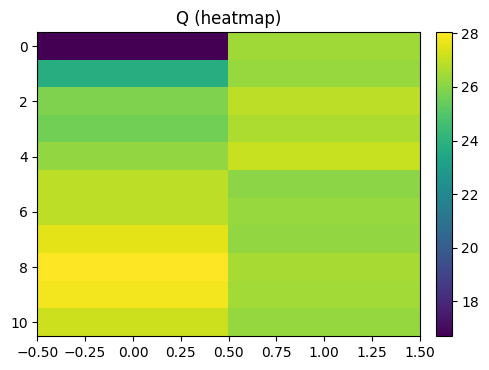

In [3]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Import names from a package/module into the notebook kernel namespace.
import numbers
# Import names from a package/module into the notebook kernel namespace.
import numpy as np
# Import names from a package/module into the notebook kernel namespace.
import matplotlib.pyplot as plt

# Function `_is_number` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _is_number(value):
    # Return a value from this function to its caller.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Function `_as_numeric_dict` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _as_numeric_dict(value):
    # Branch: only run the next indented lines when this condition is true.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Return a value from this function to its caller.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Loop header: repeat the indented block for each item in the iterable.
    for item in value.values():
        # Branch: only run the next indented lines when this condition is true.
        if not _is_number(item):
            # Return a value from this function to its caller.
            return None
        # Append one value to a list (mutates the list in place).
        converted.append(float(item))
    # Return a value from this function to its caller.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Function `_as_numeric_array` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value, dims.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Return a value from this function to its caller.
        return None
    # Branch: only run the next indented lines when this condition is true.
    if array.ndim != dims:
        # Return a value from this function to its caller.
        return None
    # Branch: only run the next indented lines when this condition is true.
    if dims == 1 and not (2 <= array.size <= 200):
        # Return a value from this function to its caller.
        return None
    # Branch: only run the next indented lines when this condition is true.
    if dims == 2 and array.size > 400:
        # Return a value from this function to its caller.
        return None
    # Return a value from this function to its caller.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math"}
# Assign/update a variable used later in this cell or in other cells.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Loop header: repeat the indented block for each item in the iterable.
for name in search_space:
    # Branch: only run the next indented lines when this condition is true.
    if name in seen or name not in globals() or name in skip_names:
        # Skip the rest of this loop body and jump to the next iteration.
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # Branch: only run the next indented lines when this condition is true.
    if dict_payload is not None:
        # Append one value to a list (mutates the list in place).
        candidates.append(("dict", name, dict_payload))
        # Branch: only run the next indented lines when this condition is true.
        if len(candidates) == 3:
            # Exit the nearest enclosing loop immediately.
            break
        # Skip the rest of this loop body and jump to the next iteration.
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # Branch: only run the next indented lines when this condition is true.
    if array_2d is not None:
        # Append one value to a list (mutates the list in place).
        candidates.append(("heatmap", name, array_2d))
        # Branch: only run the next indented lines when this condition is true.
        if len(candidates) == 3:
            # Exit the nearest enclosing loop immediately.
            break
        # Skip the rest of this loop body and jump to the next iteration.
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # Branch: only run the next indented lines when this condition is true.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        candidates.append(("line", name, array_1d))
        # Branch: only run the next indented lines when this condition is true.
        if len(candidates) == 3:
            # Exit the nearest enclosing loop immediately.
            break

# Branch: only run the next indented lines when this condition is true.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # Execute: "functions": sum(callable(value) for value in globals().values()),
        "functions": sum(callable(value) for value in globals().values()),
        # Execute: "classes": sum(isinstance(value, type) for value in globals().values()),
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # Execute: "numeric vars": sum(_is_number(value) for value in globals().values()),
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6, 3.5))
    # Configure a subplot axis (limits, ticks, labels, or artists).
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    # Configure a subplot axis (limits, ticks, labels, or artists).
    ax.set_title("Notebook artifact summary")
    # Configure a subplot axis (limits, ticks, labels, or artists).
    ax.set_ylabel("Count")
    # Loop header: repeat the indented block for each item in the iterable.
    for idx, value in enumerate(summary.values()):
        # Configure a subplot axis (limits, ticks, labels, or artists).
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.tight_layout()
    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.show()
# Else branch: runs when the matching if/elif chain was not taken.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    # Branch: only run the next indented lines when this condition is true.
    if len(candidates) == 1:
        # Assign/update a variable used later in this cell or in other cells.
        axes = [axes]

    # Loop header: repeat the indented block for each item in the iterable.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # Branch: only run the next indented lines when this condition is true.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.bar(range(len(values)), values, color="#2563eb")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_xticks(range(len(values)))
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_xticklabels(labels, rotation=45, ha="right")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_title(f"{name} (dict)")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_ylabel("Value")
        # Else-if branch: checked only when previous conditions were false.
        elif kind == "line":
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_title(f"{name} (series)")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_xlabel("Index")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_ylabel("Value")
        # Else branch: runs when the matching if/elif chain was not taken.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_title(f"{name} (heatmap)")
            # Configure or update the active Matplotlib Figure object.
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.tight_layout()
    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.show()


## Closing Takeaway

**Teaching takeaway:** SARSA learns from the action the agent actually takes, so it reflects the behavior policy more directly than Q-learning does.

**If students remember one idea:** On-policy learning means the update follows the path the current policy really experienced.

**Quick check before moving on:**
- Can you explain the structural difference between the SARSA and Q-learning update targets?
- Can you describe why SARSA can behave more cautiously during exploration?

**Bridge to the next step:** After this comparison, students can better appreciate when prediction and control updates should reflect actual behavior versus greedy targets.
